# Optimal Out of Sample Learning 

My SSR theory becomes applicable to optimally facilitating out of sample learning 
by continuously deforming the sampling distribution. 
Starting with a fully fit model on MNIST digits 0 through 8 with a large dataset, 
we continuously sample more from digits 0 through 9 instead. 
Applying an SSR regularizer with optimally forecasted $\hat \pi$ should, in theory, 
facilitate most-optimal estimation on the new distribution, leveraging old information. 

In [1]:
## dependecies 

import random 
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.nn import functional as F 
from tqdm.notebook import tqdm 
import matplotlib.pyplot as plt 

from ssr_agent import SSRAgent 
from replay_buffer import ReplayBuffer 

/anaconda/envs/azureml_py38/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
## constants 
BATCH_SIZE = 32 
LEARNING_RATE = 0.001 
SMALL_SAMPLE_SIZE = BATCH_SIZE ## otherwise loss estimates get messed-up 

In [3]:
## load data 

train_dataset = datasets.MNIST(root='/tmp/data', train=True, transform=transforms.ToTensor(), download=True) 
test_dataset = datasets.MNIST(root='/tmp/data', train=False, transform=transforms.ToTensor()) 

class MnistSampler:
    'in-memory sampler facilitating smooth traversal of statistical manifold'
    def __init__(self, mnist_dataset): 
        self.data = [] 
        for image, label in mnist_dataset: 
            self.data.append((image, label)) 
            pass 
        pass 
    def sample(self, case_a_digits={0,1,2,3,4,5,6,7,8}, prob_case_b=.1): 
        '''Randomly samples one observation via two sampling strategies:
        - Case A: Sample only from `case_a_digits`, ie. 0 through 8. 
        - Case B: Sample from all MNIST digits. 
        Case B is sampled with probability `prob_case_b`. 
        Slowly increasing `prob_case_b` from 0 to 1 simulates a simple manifold traversal. 
        '''
        is_case_b = random.uniform(0, 1) <= prob_case_b 
        sample = None 
        n = len(self.data) 
        while sample is None: 
            idx = random.randint(0, n-1) 
            x, y = self.data[idx] 
            if not is_case_b: 
                # Case A: rejection sampling 
                if y in case_a_digits: 
                    sample = x, y 
                    ## implicit else: `sample` remains `None`, keep looping 
                    pass 
            else: 
                ## Case B: no rejection sampling 
                sample = x, y 
                pass 
            pass 
        return sample 
    def sample_n(self, n, case_a_digits={0,1,2,3,4,5,6,7,8}, prob_case_b=.1): 
        x_list = [] 
        y_list = [] 
        for _ in range(n): 
            x, y = self.sample(case_a_digits=case_a_digits, prob_case_b=prob_case_b) 
            x_list.append(x) 
            y_list.append(torch.tensor(y).reshape([1,1])) 
            pass 
        x = torch.cat(x_list) 
        y = torch.cat(y_list) 
        return x, y 
    def __len__(self): 
        return len(self.data) 
    pass 

train_sampler = MnistSampler(train_dataset) 
test_sampler = MnistSampler(test_dataset) 
## yes, literally just the nines. Use `prob_case_b = 1` or it will loop infinitely 
nines_sampler = MnistSampler(torch.utils.data.Subset(test_dataset, [idx for idx in range(len(test_dataset)) if test_dataset[idx][1] == 9]))

In [4]:
## define model 

class DenseNet(SSRAgent):
    def __init__(self, replay_buffer=None, ssr_rank=5, lr=LEARNING_RATE): 
        if replay_buffer is None: 
            replay_buffer = ReplayBuffer(capacity=100000) ## need enough space for full MNIST training set 
            pass 
        super(DenseNet, self).__init__(ssr_rank=ssr_rank, replay_buffer=replay_buffer)
        self.features = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        self.__loss = nn.CrossEntropyLoss(reduction='mean') 
        self.optimizer = optim.Adam(self.parameters(), lr=lr) 
        pass 
    def forward(self, x): 
        if x.shape[0] == 0: 
            return torch.tensor([]) 
        x = x.view(x.size(0), -1) 
        x = self.features(x) 
        return x 
    def loss(self, data): 
        y_hat = self(data.x) 
        return self.__loss(y_hat, data.y.reshape([-1])) 
    def load_buffer(self, data_x, data_y): 
        self.replay_buffer.add(data_x, data_y) 
        pass 
    ## def memorize(...) ## already defined in SSRAgent parent class 
    def clear_buffer(self): 
        self.replay_buffer.clear() 
        pass 
    ## def fit(...) ## already defined in SSRAgent parent class  
    def acc(self, test_sampler=test_sampler, prob_case_b=0., batch_size=BATCH_SIZE): 
        self.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for _ in range(len(test_sampler)//batch_size): 
                x, y = test_sampler.sample_n(n=batch_size, prob_case_b=prob_case_b) 
                y_hat = model(x) 
                _, predicted = torch.max(y_hat.data, 1) 
                predicted = predicted.reshape([-1,1]) 
                total += y.size(0) 
                correct += (predicted == y).sum().item() 
                pass 
            pass 
        return correct / total ## acc 
    pass 

In [5]:
## initial fit, takes about 10 seconds on a CPU 

model = DenseNet() 
x, y = train_sampler.sample_n(5000, prob_case_b=0.) ## all Case A for initial fit 
model.load_buffer(x, y) 
tq = tqdm(range(1000))
for idx in tq: 
    if idx % 100 == 0: 
        acc = model.acc() 
        tq.set_description(f'accuracy: {round(acc,4)}') 
        pass 
    model.fit(iters=1, batch_size=BATCH_SIZE) 
    pass 
print(f'final accuracy: {round(acc,4)}') 

  0%|          | 0/1000 [00:00<?, ?it/s]

final accuracy: 0.9377


In [6]:
## memorize and discard, takes about 2.5 minutes on a CPU 

model.memorize() 
model.clear_buffer() 

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
## efficiently traverse the statistical manifold 

acc_all_list = [] 
acc_nines_list = [] 
pi_list = [] 
prob_case_b_list = [(idx+1)/50 for idx in range(50)] 
tq = tqdm(prob_case_b_list) 
for prob_case_b in tq: 
    ## get data spiked with more and more 9s 
    x, y = train_sampler.sample_n(SMALL_SAMPLE_SIZE, prob_case_b=prob_case_b) 
    model.load_buffer(x, y) 
    ## fit, memorize, and clear 
    pi, _ = model.fit(iters=1, batch_size=SMALL_SAMPLE_SIZE, pi_min=.01, pi_max=.9) 
    model.memorize(disable_tqdm=True) 
    model.clear_buffer() 
    ## get key performance indicators 
    acc_all = model.acc(test_sampler=test_sampler, prob_case_b=prob_case_b) 
    acc_nines = model.acc(test_sampler=nines_sampler, prob_case_b=1.) 
    tq.set_description(f'acc: {round(acc_all ,4)},  acc9: {round(acc_nines, 4)}, pi: {round(pi, 4)}') 
    ## record for plotting 
    acc_all_list.append(acc_all) 
    acc_nines_list.append(acc_nines) 
    pi_list.append(pi) 
    pass 

  0%|          | 0/50 [00:00<?, ?it/s]

DEBUG 1: 2*dt_mean_trend: 0.0, dt_mean_trace_cov: 0.0
DEBUG 1: 2*dt_mean_trend: 1.2028980255126953, dt_mean_trace_cov: 4.871737480163574
DEBUG 1: 2*dt_mean_trend: 1.011090636253357, dt_mean_trace_cov: 4.452932834625244
DEBUG 1: 2*dt_mean_trend: 0.8579628467559814, dt_mean_trace_cov: 4.068853378295898
DEBUG 1: 2*dt_mean_trend: 0.678606390953064, dt_mean_trace_cov: 3.7717528343200684
DEBUG 1: 2*dt_mean_trend: 0.6052948236465454, dt_mean_trace_cov: 3.511141300201416
DEBUG 1: 2*dt_mean_trend: 0.6153499484062195, dt_mean_trace_cov: 3.2302424907684326
DEBUG 1: 2*dt_mean_trend: 0.6574605703353882, dt_mean_trace_cov: 2.961679697036743
DEBUG 1: 2*dt_mean_trend: 0.6969138383865356, dt_mean_trace_cov: 2.7265164852142334
DEBUG 1: 2*dt_mean_trend: 0.7582652568817139, dt_mean_trace_cov: 2.5050530433654785
DEBUG 1: 2*dt_mean_trend: 0.7985661029815674, dt_mean_trace_cov: 2.2992444038391113
DEBUG 1: 2*dt_mean_trend: 0.8346652388572693, dt_mean_trace_cov: 2.1023941040039062
DEBUG 1: 2*dt_mean_trend: 0.8

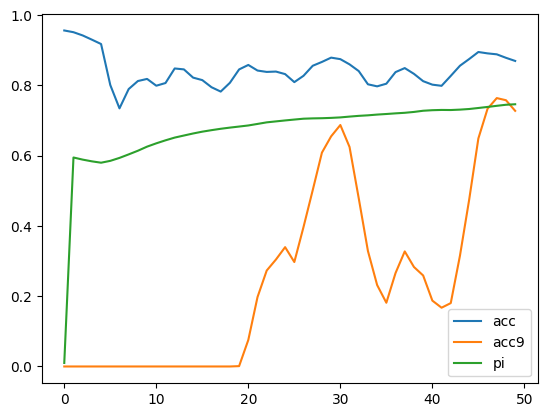

In [8]:
plt.plot(acc_all_list, label='acc') 
plt.plot(acc_nines_list, label='acc9') 
plt.plot(pi_list, label='pi') 
plt.legend() 
plt.show() 